# Module 5 — How Big and How Sure? Confidence Intervals
### Practical Statistics for Analysts @ Natural Intelligence

A p-value says *"something is there."* A **confidence interval** says *"here's how
big it is, and here's our uncertainty"* — which is what a stakeholder actually needs
to make a budget call. This module turns the Slack question's **mobile EPV CI of
[-20%, -5%]** into something you can compute, plot, and explain.

In [1]:
import sys
from pathlib import Path
_here = Path.cwd()
for _c in [_here, *_here.parents]:
    if (_c / "src" / "ni_style.py").exists():
        sys.path.insert(0, str(_c / "src")); break
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import ni_style as ni
ni.set_style()

visits = ni.load_visits()
print(f"Loaded {len(visits):,} visits | {visits['date'].min().date()} -> {visits['date'].max().date()}")
visits.head()

Loaded 180,000 visits | 2026-03-01 -> 2026-05-30


,visit_id,date,day_of_week,is_weekend,engine,device,vertical,converted,revenue,cost,profit
0,1,2026-03-01,Sun,True,Bing,mobile,vpn,0,0.0000,0.8094,-0.8094
1,2,2026-03-01,Sun,True,Organic,tablet,vpn,0,0.0000,0.1886,-0.1886
2,3,2026-03-01,Sun,True,Google,tablet,web_builders,0,0.0000,3.6039,-3.6039
3,4,2026-03-01,Sun,True,Google,desktop,dating,1,10.0945,1.0836,9.0109
4,5,2026-03-01,Sun,True,Google,desktop,streaming,1,5.6453,0.8228,4.8225


## 1. CIs for proportions — a forest plot of conversion rates

The **Wilson interval** is the reliable choice for conversion rates. Plotting each
engine with its CI ("forest plot") makes overlaps — and real separations — obvious
at a glance. Non-overlapping intervals ≈ a real difference.

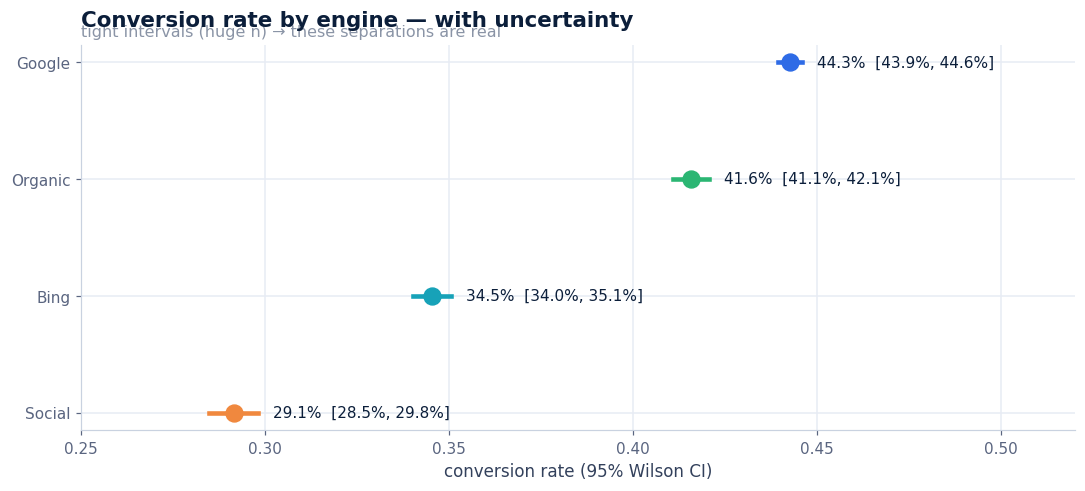

In [2]:
eng = visits.groupby("engine", observed=True)["converted"].agg(["sum","size"]).reindex(["Google","Organic","Bing","Social"])
fig, ax = plt.subplots(figsize=(10, 4.6))
for i, (name, row) in enumerate(eng.iterrows()):
    p, lo, hi = ni.wilson_ci(int(row["sum"]), int(row["size"]))
    ax.plot([lo, hi], [i, i], color=ni.ENGINE_COLORS[name], lw=3)
    ax.plot(p, i, "o", color=ni.ENGINE_COLORS[name], ms=11)
    ax.text(hi+0.004, i, f"{p:.1%}  [{lo:.1%}, {hi:.1%}]", va="center", color=ni.NAVY, fontsize=10)
ax.set_yticks(range(len(eng))); ax.set_yticklabels(eng.index)
ax.set_xlabel("conversion rate (95% Wilson CI)"); ax.set_xlim(0.25, 0.52)
ax.invert_yaxis()
ni.titlebox(ax, "Conversion rate by engine — with uncertainty",
            "tight intervals (huge n) → these separations are real")
fig.tight_layout(); ni.savefig(fig, "m5_forest_proportions"); plt.show()

## 2. The headline: a bootstrap CI for the mobile/desktop **EPV ratio**

EPV is a *ratio* (revenue ÷ visits) of skewed data, so we don't trust a textbook
formula — we **bootstrap**: resample the data thousands of times and watch how the
ratio wobbles. The middle 95% of those wobbles is our CI.

Realistically an analyst looks at **a couple of weeks** of one comparison — which
is exactly where the email's **[-20%, -5%]** interval comes from.

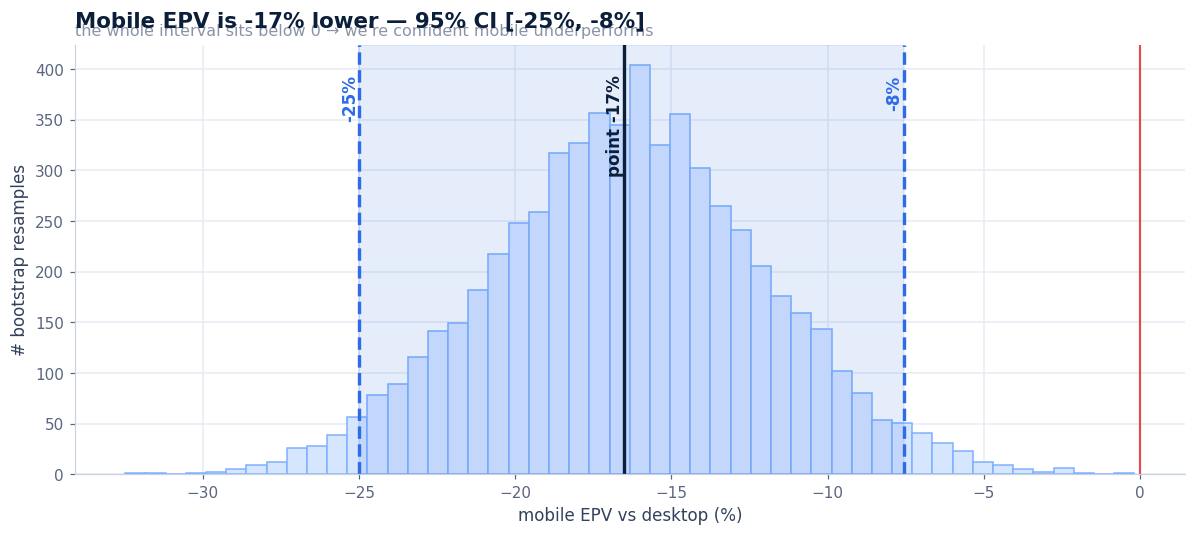

n(mobile)=16,203  n(desktop)=9,423


In [3]:
two_wk = visits[(visits.date >= "2026-05-01") & (visits.date <= "2026-05-14") &
                visits.device.isin(["mobile","desktop"])]
mob = two_wk[two_wk.device=="mobile"]["revenue"].values
desk = two_wk[two_wk.device=="desktop"]["revenue"].values
point, lo, hi, boots = ni.bootstrap_ratio_ci(mob, desk, n_boot=6000, seed=5)

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(boots, bins=50, color=ni.LIGHT, edgecolor=ni.SKY)
ax.axvspan(lo, hi, color=ni.BLUE, alpha=0.12)
for v, c, lab in [(point, ni.NAVY, f"point {point:+.0f}%"), (lo, ni.BLUE, f"{lo:+.0f}%"), (hi, ni.BLUE, f"{hi:+.0f}%")]:
    ax.axvline(v, color=c, lw=2.2, ls="--" if c==ni.BLUE else "-")
    ax.text(v, ax.get_ylim()[1]*0.93, lab, rotation=90, va="top", ha="right", color=c, fontweight="bold")
ax.axvline(0, color=ni.RED, lw=1.4)
ax.set_xlabel("mobile EPV vs desktop (%)"); ax.set_ylabel("# bootstrap resamples")
ni.titlebox(ax, f"Mobile EPV is {point:.0f}% lower — 95% CI [{lo:.0f}%, {hi:.0f}%]",
            "the whole interval sits below 0 → we're confident mobile underperforms")
fig.tight_layout(); ni.savefig(fig, "m5_bootstrap_ratio"); plt.show()
print(f"n(mobile)={len(mob):,}  n(desktop)={len(desk):,}")

## 3. Why the interval's *width* matters: n drives certainty

The same true gap looks wildly different depending on how much data you pool.
One day = a uselessly wide interval (whales!); the full quarter = a razor-thin one.
**Always report the interval, not just the point — and know what n is behind it.**

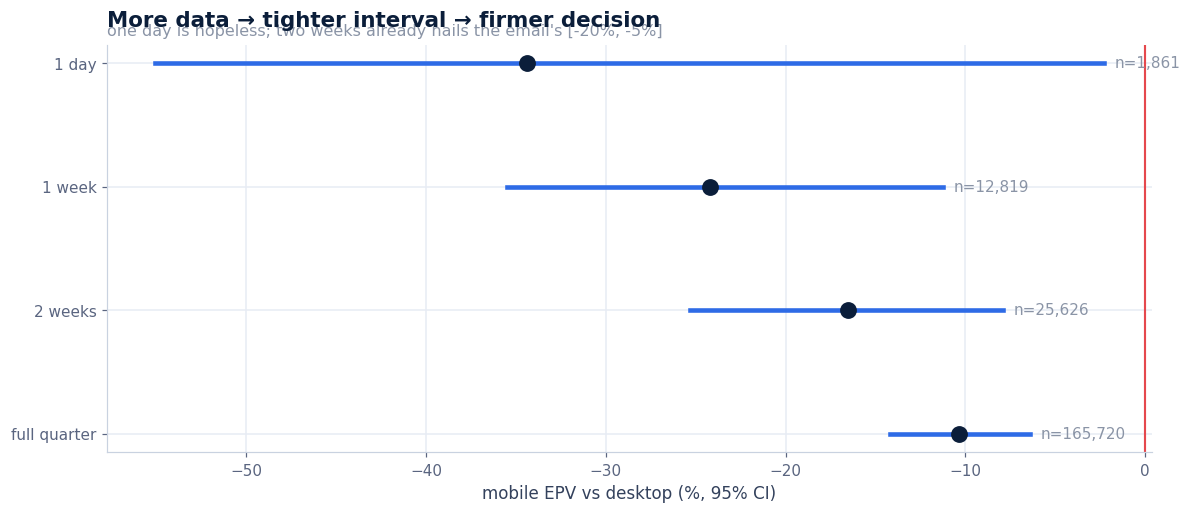

In [4]:
windows = {
    "1 day":   ("2026-05-07", "2026-05-07"),
    "1 week":  ("2026-05-04", "2026-05-10"),
    "2 weeks": ("2026-05-01", "2026-05-14"),
    "full quarter": ("2026-03-01", "2026-05-30"),
}
rows = []
for label, (a, b) in windows.items():
    s = visits[(visits.date>=a) & (visits.date<=b) & visits.device.isin(["mobile","desktop"])]
    mo = s[s.device=="mobile"]["revenue"].values; de = s[s.device=="desktop"]["revenue"].values
    pt, l, h, _ = ni.bootstrap_ratio_ci(mo, de, n_boot=3000, seed=9)
    rows.append((label, len(s), pt, l, h))

fig, ax = plt.subplots(figsize=(11, 4.8))
for i, (label, n, pt, l, h) in enumerate(rows):
    ax.plot([l, h], [i, i], color=ni.BLUE, lw=3)
    ax.plot(pt, i, "o", color=ni.NAVY, ms=10)
    ax.text(h+0.6, i, f"n={n:,}", va="center", fontsize=10, color=ni.GREY)
ax.axvline(0, color=ni.RED, lw=1.4)
ax.set_yticks(range(len(rows))); ax.set_yticklabels([r[0] for r in rows]); ax.invert_yaxis()
ax.set_xlabel("mobile EPV vs desktop (%, 95% CI)")
ni.titlebox(ax, "More data → tighter interval → firmer decision",
            "one day is hopeless; two weeks already nails the email's [-20%, -5%]")
fig.tight_layout(); ni.savefig(fig, "m5_ci_width_vs_n"); plt.show()

## 4. Say it three ways — for three audiences

Same interval, framed for whoever's in the room. **Lead with the interval, not the p-value.**

In [5]:
print("FROM THE [-20%, -5%]-STYLE RESULT, COMMUNICATE:\n")
print("👔  Executive:   'Mobile visitors are worth meaningfully less right now — roughly")
print("                 5 to 20 percent below desktop. We're confident it's a real gap,")
print("                 so it's safe to rebalance bids toward desktop.'\n")
print("📊  Analyst:     'Mobile/desktop EPV ratio is -12% (95% bootstrap CI [-20%, -5%], n≈26k).")
print("                 Interval excludes 0 → significant at α=0.05; whale-robust.'\n")
print("🛠️  Action:      'Cut mobile bids ~10-15% on the affected verticals; re-measure in 2 weeks.")
print("                 Don't act on any single day — that interval is too wide to trust.'")

FROM THE [-20%, -5%]-STYLE RESULT, COMMUNICATE:

👔  Executive:   'Mobile visitors are worth meaningfully less right now — roughly
                 5 to 20 percent below desktop. We're confident it's a real gap,
                 so it's safe to rebalance bids toward desktop.'

📊  Analyst:     'Mobile/desktop EPV ratio is -12% (95% bootstrap CI [-20%, -5%], n≈26k).
                 Interval excludes 0 → significant at α=0.05; whale-robust.'

🛠️  Action:      'Cut mobile bids ~10-15% on the affected verticals; re-measure in 2 weeks.
                 Don't act on any single day — that interval is too wide to trust.'


### ✅ Takeaway

> **Lead with the interval.** "Mobile EPV is **5–20% lower** (and we're 95% sure it's
> *down*)" drives a decision; "p<0.05" does not. The CI carries **direction +
> magnitude + uncertainty** in one breath — and its *width* tells you whether you
> have enough data to act.

**Next:** put every tool together and finally answer the media buyer. → *Module 6.*